# 15.5.1 已知收支加可学习修正

## 学习目标与先修知识

给机制项和修正项分别标单位，并在新输入（input）下比较机制与混合模型（model）。

先修：15.4 方程残差（residual）；1.2 收支（mass balance）；14.5 独立条件比较。

## 具体问题

单室清除的线性机制在某些浓度（concentration）下出现系统误差。加入一个小型函数修正后，如何确认它改善的是独立预测，而不是只记住训练输入？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先作数值预测，再与完整模型对照。

In [2]:
x,u,k,theta,scale=.8,.4,.4,-.1,1.;print("机制右端：",u-k*x,"；修正右端：",theta*np.tanh(x/scale))

机制右端： 0.07999999999999996 ；修正右端： -0.0664036770267849


## 模型假设

x 是总量 U，u 是输入率 U/T，k 是 1/T；修正 $\theta\tanh(x/s)$ 的 $\theta$ 单位 U/T、s 单位 U。状态（state）非负、输入非负。本节使用固定 Euler 时间步，所有模型在相同步长和观测（observation）上比较；训练只用第一种输入。

## 数学解释与推导

混合右端为 $\dot x=u-kx+g_\theta(x)$，$g_\theta(x)=\theta\tanh(x/s)$。当 $\theta=0$，恢复机制模型。拟合 $\theta$ 时预先固定 $k$ 和 $s$，否则参数（parameter）补偿可能妨碍辨识。训练损失仅由第一种输入下的观测构成；改变输入后的整条轨迹（trajectory）用于独立检查。总量收支中的修正属于附加源或汇，若没有机制证据不能仅凭拟合称它为真实清除通道。

## 核心实现

下面的函数保留计算步骤，可逐行修改并核对。

In [3]:
def hybrid_rhs(x, u, k, theta, scale):
    return float(u-k*x+theta*math.tanh(x/scale))


def hybrid_euler(x0, inputs, h, k, theta, scale):
    states = [float(x0)]
    for u in inputs:
        states.append(states[-1]+h*hybrid_rhs(states[-1],float(u),k,theta,scale))
    return states

## 对照实验

先在输入 0.4 U/T 的轨迹上拟合修正幅度，再把输入改为 0.8 U/T，比较机制基线与混合模型的预测。

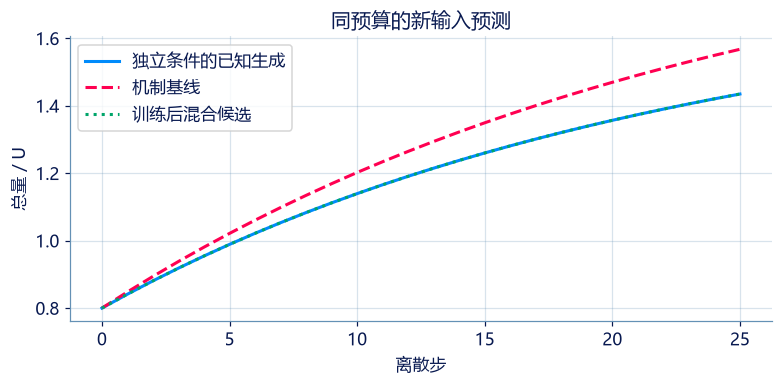

训练估计修正参数： -0.09999999999999999 ；新输入 RMSE（机制/混合）： 0.08308722155984535 0.0


In [4]:
h=.1;train_input=[.4]*25;held_input=[.8]*25;x0=.8;k=.4;scale=1.;true_theta=-.1
train=np.array(hybrid_euler(x0,train_input,h,k,true_theta,scale));grid=np.linspace(-.2,.1,61)
chosen=min(grid,key=lambda th:np.mean((np.array(hybrid_euler(x0,train_input,h,k,float(th),scale))-train)**2))
truth=np.array(hybrid_euler(x0,held_input,h,k,true_theta,scale));mech=np.array(hybrid_euler(x0,held_input,h,k,0.,scale));hybrid=np.array(hybrid_euler(x0,held_input,h,k,float(chosen),scale))
fig,ax=plt.subplots(figsize=(7,3.4));ax.plot(truth,label="独立条件的已知生成",color=BLUE);ax.plot(mech,"--",label="机制基线",color=PINK);ax.plot(hybrid,":",label="训练后混合候选",color=GREEN);ax.set(xlabel="离散步",ylabel="总量 / U",title="同预算的新输入预测");ax.legend();ax.grid(alpha=.25);plt.show()
print("训练估计修正参数：",chosen,"；新输入 RMSE（机制/混合）：",np.sqrt(np.mean((mech-truth)**2)),np.sqrt(np.mean((hybrid-truth)**2)))

## 结果解释

本人工例中固定机制参数后，小修正可在新输入下改善预测；这是给定模型族和输入范围内的证据，不足以证明修正项对应唯一生物机制。若修正改变符号或初值（initial condition）超出训练范围，应另验非负性（nonnegativity）与稳定性。

### 独立核对

对本节的核心结果使用解析值、代数恒等式或独立差分核对。

In [5]:
np.testing.assert_allclose(hybrid_rhs(.8,.4,.4,0.,1.),.4-.4*.8)
np.testing.assert_allclose(hybrid_euler(.8,[.4]*3,.1,.4,0.,1.),[.8,.808,.81568,.823053],atol=1e-5)
assert abs(chosen-true_theta)<1e-10
print("零修正极限、Euler 手算与训练参数核验通过。")

零修正极限、Euler 手算与训练参数核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/explore/)：先预测，再查看结果与简化假设。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：零修正的极限

混合右端 u-kx+θ tanh(x/s) 在 θ=0 时应怎样？

- **A.** 状态（state）导数（derivative）总为零。
- **B.** 成为任意神经网络（neural network）。
- **C.** 只保留输入（input） u。
- **D.** 精确恢复 u-kx 的机制基线。

[作答：零修正的极限](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/practice/?question=p15-zero-correction)

### 第 2 题 · 单项选择题：拟合与机制

混合模型（model）训练损失下降且新输入（input）预测改善，可以直接断言修正项是真实生理通道吗？

- **A.** 不能；它支持给定条件下的预测，还需结构可辨识与额外机制证据。
- **B.** 能，因为任何 tanh 都是生理清除。
- **C.** 能，因为总量非负。
- **D.** 能，因为训练参数（parameter）唯一。

[作答：拟合与机制](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/practice/?question=p15-mechanism-claim)

### 第 3 题 · Python 计算题：机制与修正的总变化率

计算给定状态（state）、输入（input）率及修正参数（parameter）下的混合右端。

**函数与代码模板**

```python
def solve(
    x: float,
    u: float,
    k: float,
    theta: float,
    scale: float,
) -> float:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x` | `float` | 当前总量。 | U |
| `u` | `float` | 输入率。 | U/T |
| `k` | `float` | 机制消除系数。 | 1/T |
| `theta` | `float` | 修正幅度。 | U/T |
| `scale` | `float` | 正的状态尺度。 | U |

**返回值**

直接返回 rate（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rate` | `float` | 当前总量变化率。 | U/T |

**计算规则**

变化率 = u-k*x+theta*tanh(x/scale)。

**约束与边界**

- scale>0，x≥0，u≥0，k≥0；全部有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x | 当前总量。 | 0 | U |
| u | 输入率。 | 0.4 | U/T |
| k | 机制消除系数。 | 0.3 | 1/T |
| theta | 修正幅度。 | -0.1 | U/T |
| scale | 正的状态尺度。 | 1 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x = 0.0
u = 0.4
k = 0.3
theta = -0.1
scale = 1.0

result = solve(x, u, k, theta, scale)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rate | 当前总量变化率。 | 0.4 | U/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.4
```

**样例解释**

x=0 时平滑修正为0，右端等于输入率。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：机制与修正的总变化率](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/practice/?question=p15-hybrid-right-side)

### 第 4 题 · Python 计算题：混合模型的固定步长轨迹

用显式 Euler 推进已知输入（input）率序列，返回包含初态的全部总量。

**函数与代码模板**

```python
def solve(
    x0: float,
    inputs: list[float],
    h: float,
    k: float,
    theta: float,
    scale: float,
) -> list[float]:
    # 按题给公式完成计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `x0` | `float` | 初态。 | U |
| `inputs` | `list[float]` | 各步输入率。 | U/T |
| `h` | `float` | 时间步长（time step）。 | T |
| `k` | `float` | 消除系数。 | 1/T |
| `theta` | `float` | 修正幅度。 | U/T |
| `scale` | `float` | 正尺度。 | U |

**返回值**

直接返回 states（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[float]` | 初态与逐步更新的总量。 | U |

**计算规则**

按 x_new=x+h*(u-k*x+theta*tanh(x/scale)) 逐步推进，返回含初态路径。

**约束与边界**

- scale>0，h>0，k≥0，输入非负，步数不超过100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| x0 | 初态。 | 1 | U |
| inputs | 各步输入率。 | [0.0, 0.0] | U/T |
| h | 时间步长（time step）。 | 0.1 | T |
| k | 消除系数。 | 0.5 | 1/T |
| theta | 修正幅度。 | 0 | U/T |
| scale | 正尺度。 | 1 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
x0 = 1.0
inputs = [0.0, 0.0]
h = 0.1
k = 0.5
theta = 0.0
scale = 1.0

result = solve(x0, inputs, h, k, theta, scale)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 初态与逐步更新的总量。 | [1.0, 0.95, 0.9025] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [1.0, 0.95, 0.9025]
```

**样例解释**

零修正、零输入时首例前两步依次乘以1-kh。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：混合模型的固定步长轨迹](http://127.0.0.1:8000/chapters/15-05-%E6%B7%B7%E5%90%88%E6%A8%A1%E5%9E%8B%E4%B8%8E%E5%8F%AF%E8%BE%A8%E8%AF%86%E6%80%A7/practice/?question=p15-hybrid-steps)

**进一步阅读**

[Chen 等](https://papers.nips.cc/paper_files/paper/2018/file/69386f6bb1dfed68692a24c8686939b9-Paper.pdf)提供可学习连续右端背景；混合收支是本课程教学构造。